In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.express as px
#load data
df = pd.read_csv(r"C:\Users\gkteb\Documents\Docuware Data Analysis\workflow_completed_steps.csv", sep=';')



In [2]:
#sort data
df['completion_time'] = pd.to_datetime(df['completion_time'])
df


,workflow_ID,step_type,step_order,step_name,completion_time
0,QueueDocuments,Data assignment,1,Assign data,2026-02-03 15:38:08
1,QueueDocuments,Condition,2,Check If Previous Doc Not Deleted,2026-02-03 15:38:08
2,QueueDocuments,Time delay,3,Wait for Queue,2026-02-03 15:39:10
3,QueueDocuments,Data assignment,4,Assign Queue Number,2026-02-03 15:39:10
4,QueueDocuments,Condition,5,Check if Previous Document Extracted,2026-02-03 15:39:10
...,...,...,...,...,...
385,7PurchaseInvoice,Web service,237,Submit Inv Data,2026-02-03 17:45:49
386,7PurchaseInvoice,Condition,238,Check if Success,2026-02-03 17:45:49
387,7PurchaseInvoice,Data assignment,239,Assign Webservice Call Data Back to Document,2026-02-03 17:45:49
388,7PurchaseInvoice,Data assignment,240,Assign PO Status,2026-02-03 17:45:49


In [3]:

df = df.sort_values(by=['step_order','workflow_ID'])
df

,workflow_ID,step_type,step_order,step_name,completion_time
0,QueueDocuments,Data assignment,1,Assign data,2026-02-03 15:38:08
1,QueueDocuments,Condition,2,Check If Previous Doc Not Deleted,2026-02-03 15:38:08
2,QueueDocuments,Time delay,3,Wait for Queue,2026-02-03 15:39:10
3,QueueDocuments,Data assignment,4,Assign Queue Number,2026-02-03 15:39:10
4,QueueDocuments,Condition,5,Check if Previous Document Extracted,2026-02-03 15:39:10
...,...,...,...,...,...
385,7PurchaseInvoice,Web service,237,Submit Inv Data,2026-02-03 17:45:49
386,7PurchaseInvoice,Condition,238,Check if Success,2026-02-03 17:45:49
387,7PurchaseInvoice,Data assignment,239,Assign Webservice Call Data Back to Document,2026-02-03 17:45:49
388,7PurchaseInvoice,Data assignment,240,Assign PO Status,2026-02-03 17:45:49


In [4]:
#Calculate Step Duration
df['prev_completed_time'] = df.groupby('workflow_ID')['completion_time'].shift(1)

df['duration_minutes'] = (
    df['completion_time'] - df['prev_completed_time']
).dt.total_seconds() / 60

df

,workflow_ID,step_type,step_order,step_name,completion_time,prev_completed_time,duration_minutes
0,QueueDocuments,Data assignment,1,Assign data,2026-02-03 15:38:08,NaT,NaN
1,QueueDocuments,Condition,2,Check If Previous Doc Not Deleted,2026-02-03 15:38:08,2026-02-03 15:38:08,0.000000
2,QueueDocuments,Time delay,3,Wait for Queue,2026-02-03 15:39:10,2026-02-03 15:38:08,1.033333
3,QueueDocuments,Data assignment,4,Assign Queue Number,2026-02-03 15:39:10,2026-02-03 15:39:10,0.000000
4,QueueDocuments,Condition,5,Check if Previous Document Extracted,2026-02-03 15:39:10,2026-02-03 15:39:10,0.000000
...,...,...,...,...,...,...,...
385,7PurchaseInvoice,Web service,237,Submit Inv Data,2026-02-03 17:45:49,2026-02-03 17:45:49,0.000000
386,7PurchaseInvoice,Condition,238,Check if Success,2026-02-03 17:45:49,2026-02-03 17:45:49,0.000000
387,7PurchaseInvoice,Data assignment,239,Assign Webservice Call Data Back to Document,2026-02-03 17:45:49,2026-02-03 17:45:49,0.000000
388,7PurchaseInvoice,Data assignment,240,Assign PO Status,2026-02-03 17:45:49,2026-02-03 17:45:49,0.000000


In [5]:
bottleneck = (
    df.dropna()
      .groupby('step_name')['duration_minutes']
      .mean()
      .sort_values(ascending=False)
)

bottleneck

step_name
Check Amount Line item             5.438333e+01
Completion                         1.077500e+01
Wait for data to update            9.083333e+00
Assign Inv Data                    2.166667e+00
Assign PI Number from Palladium    1.909259e+00
                                       ...     
Increment PI Number               -9.868649e-17
Mod 45                            -2.089832e-16
Increment Count                   -1.274510e-01
Validation                        -1.983333e+00
Incorrect tax amount              -1.983333e+00
Name: duration_minutes, Length: 196, dtype: float64

In [6]:


bottleneck = df.groupby('step_name')['duration_minutes'].mean()



In [7]:
bottleneck_top = bottleneck.sort_values(ascending=False)


<Axes: ylabel='step_name'>

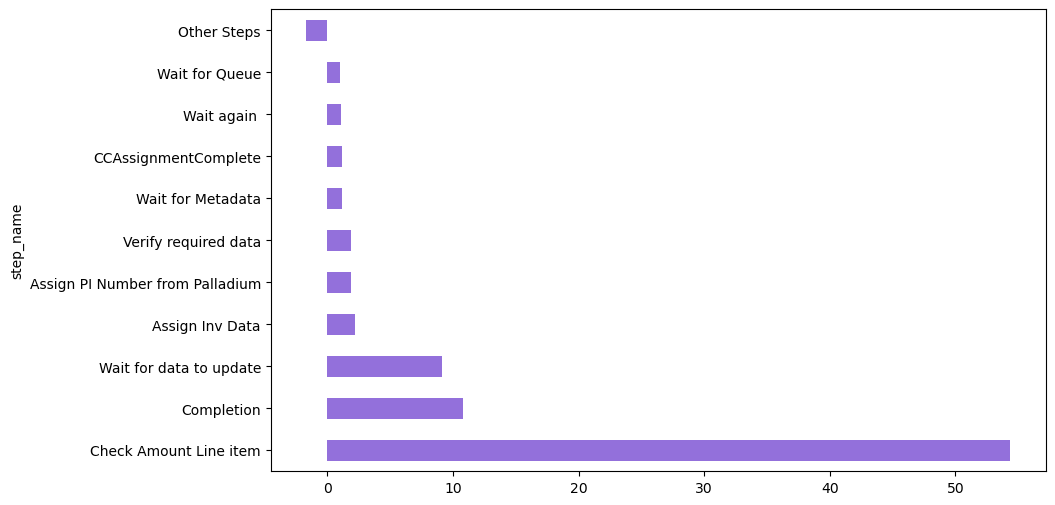

In [8]:
top10 = bottleneck.sort_values(ascending=False).head(10)
others = bottleneck.sum() - top10.sum()
top10['Other Steps'] = others

top10.plot(kind='barh', color='mediumpurple', figsize=(10,6))

In [9]:
# Combine workflow ID and step name into a single label
df['workflow_step'] = df['workflow_ID'] + " - " + df['step_name']

In [10]:
df

,workflow_ID,step_type,step_order,step_name,completion_time,prev_completed_time,duration_minutes,workflow_step
0,QueueDocuments,Data assignment,1,Assign data,2026-02-03 15:38:08,NaT,NaN,QueueDocuments - Assign data
1,QueueDocuments,Condition,2,Check If Previous Doc Not Deleted,2026-02-03 15:38:08,2026-02-03 15:38:08,0.000000,QueueDocuments - Check If Previous Doc Not Del...
2,QueueDocuments,Time delay,3,Wait for Queue,2026-02-03 15:39:10,2026-02-03 15:38:08,1.033333,QueueDocuments - Wait for Queue
3,QueueDocuments,Data assignment,4,Assign Queue Number,2026-02-03 15:39:10,2026-02-03 15:39:10,0.000000,QueueDocuments - Assign Queue Number
4,QueueDocuments,Condition,5,Check if Previous Document Extracted,2026-02-03 15:39:10,2026-02-03 15:39:10,0.000000,QueueDocuments - Check if Previous Document Ex...
...,...,...,...,...,...,...,...,...
385,7PurchaseInvoice,Web service,237,Submit Inv Data,2026-02-03 17:45:49,2026-02-03 17:45:49,0.000000,7PurchaseInvoice - Submit Inv Data
386,7PurchaseInvoice,Condition,238,Check if Success,2026-02-03 17:45:49,2026-02-03 17:45:49,0.000000,7PurchaseInvoice - Check if Success
387,7PurchaseInvoice,Data assignment,239,Assign Webservice Call Data Back to Document,2026-02-03 17:45:49,2026-02-03 17:45:49,0.000000,7PurchaseInvoice - Assign Webservice Call Data...
388,7PurchaseInvoice,Data assignment,240,Assign PO Status,2026-02-03 17:45:49,2026-02-03 17:45:49,0.000000,7PurchaseInvoice - Assign PO Status


In [11]:
#calculate average duration if multiple entries per workflow_step
bottleneck = df.groupby('workflow_step')['duration_minutes'].mean()
bottleneck = bottleneck.sort_values(ascending=False)

<Axes: ylabel='workflow_step'>

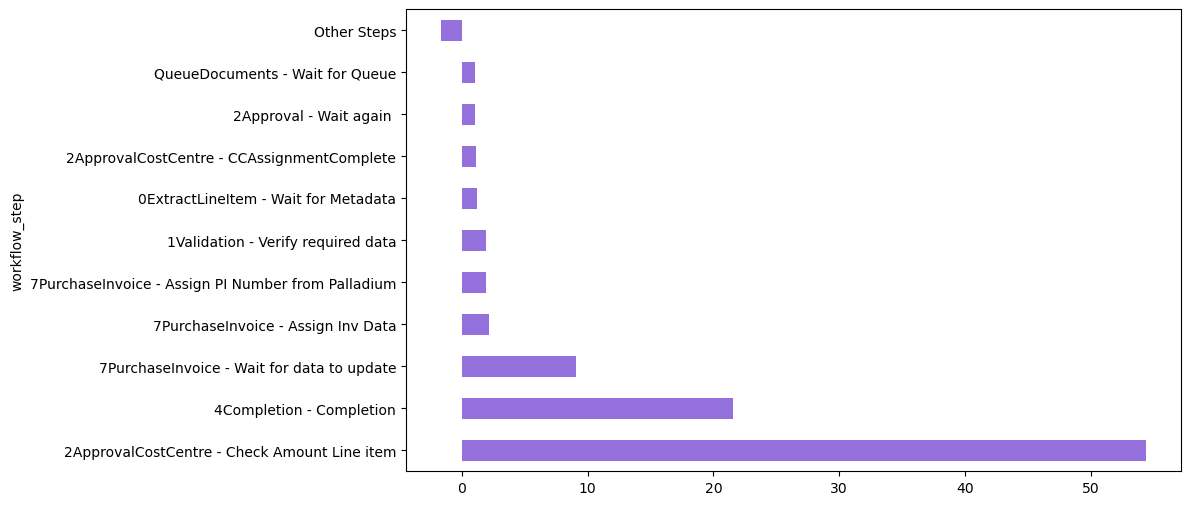

In [15]:
top10 = bottleneck.sort_values(ascending=False).head(10)
others = bottleneck.sum() - top10.sum()
top10['Other Steps'] = others

top10.plot(kind='barh', color='mediumpurple', figsize=(10,6))